# 16.3.2 估计进入控制的时间顺序

## 学习目标与先修知识

按旧估计决策、观测（observation）新状态（state）、再更新估计的顺序比较漂移。

先修：16.3.1 递推估计；执行限幅与离散状态。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

自校正控制在参数（parameter）变化时可能跟踪较好。能否在做本步控制前，偷偷用本步末状态更新估计？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x=1.;a_hat=.6;target=1.;u=np.clip(target-a_hat*x,-.5,.5);print("由旧估计选择的输入：",u)

由旧估计选择的输入： 0.4


## 模型假设

真实状态更新 $x_{n+1}=a_nx_n+u_n$，输入（input）增益（gain）已知为正且等于1；$a_n$ 在 $[0,1]$，控制 $|u|\le0.5$ U。当前决策只读取当前状态和过去估计，新状态到来后才更新。变化参数不满足固定参数收敛定理。

## 数学解释与推导

本步请求 $u_n^\star=r_{n+1}-\hat a_nx_n$，执行 $u_n=\operatorname{clip}(u_n^\star)$；观测 $x_{n+1}$ 后令 $y_n=x_{n+1}-u_n$，再用 $\phi_n=x_n$ 更新估计。若提前用 $x_{n+1}$ 修改 $\hat a_n$ 再选 $u_n$，就把未来结果泄漏给控制器。跟踪指标、参数误差和限幅频率应分别报告。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def rls_scalar(regressors,targets,theta0,p0,forget,low,high):
    theta=float(theta0);P=float(p0);estimates=[theta]
    for phi,target in zip(regressors,targets):
        gain=P*phi/(forget+phi*phi*P)
        theta=float(np.clip(theta+gain*(target-phi*theta),low,high))
        P=(P-gain*phi*P)/forget
        estimates.append(theta)
    return [estimates,float(P)]


def adaptive_path(x0,true_coefficients,references,theta0,p0,forget,limit,low,high):
    x=float(x0);theta=float(theta0);P=float(p0)
    states=[x];inputs=[];estimates=[theta]
    for actual_a,reference in zip(true_coefficients,references):
        requested=reference-theta*x
        u=float(np.clip(requested,-limit,limit))
        next_x=actual_a*x+u
        gain=P*x/(forget+x*x*P)
        theta=float(np.clip(theta+gain*((next_x-u)-theta*x),low,high))
        P=(P-gain*x*P)/forget
        states.append(float(next_x));inputs.append(u);estimates.append(theta)
        x=next_x
    return [states,inputs,estimates]

## 对照实验

在第 12 步后将生成参数从 0.8 改为 0.65，观察估计跟上变化所需的时间、状态跟踪和执行限幅次数。

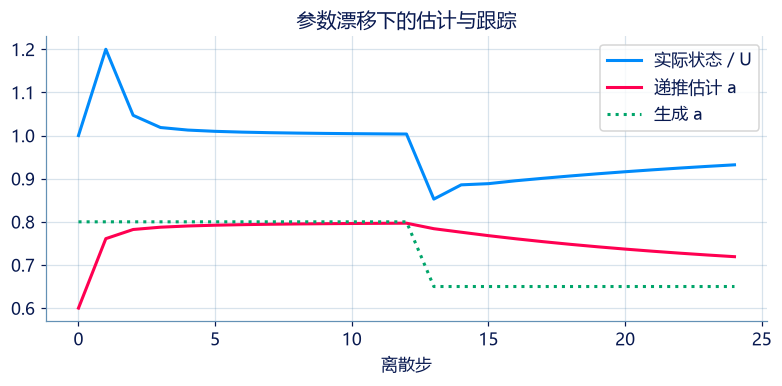

平均跟踪绝对差与限幅次数： 0.06092976983185666 0


In [4]:
coeff=[.8]*12+[.65]*12;ref=[1.]*24
states,inputs,est=adaptive_path(1.,coeff,ref,.6,4.,.97,.5,0.,1.)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(states,label="实际状态 / U",color=BLUE);ax.plot(est,label="递推估计 a",color=PINK);ax.plot([coeff[0]]+[x for x in coeff],":",label="生成 a",color=GREEN);ax.set(xlabel="离散步",title="参数漂移下的估计与跟踪");ax.legend();ax.grid(alpha=.25);plt.show()
print("平均跟踪绝对差与限幅次数：",np.mean(np.abs(np.asarray(states[1:])-1)),sum(abs(x)>=.5 for x in inputs))

## 结果解释

估计更新落后于参数漂移，跟踪也受执行限幅影响。因此需要分别观察参数估计与跟踪误差：输出（output）靠近目标时，参数估计仍可能落后。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert len(states)==25 and len(inputs)==24 and len(est)==25
for n,(a,u) in enumerate(zip(coeff,inputs)):np.testing.assert_allclose(states[n+1],a*states[n]+u)
assert all(0<=x<=1 for x in est)
print("每步真实推进、估计范围和时序核验通过。")

每步真实推进、估计范围和时序核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：在线控制的信息边界

在选择 u_n 时，下列哪项不可用？

- **A.** 当前状态（state） x_n。
- **B.** 过去更新的估计 a_hat_n。
- **C.** 本步末尚未发生的 x_{n+1}。
- **D.** 已知的输入（input）上限。

[作答：在线控制的信息边界](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-no-lookahead)

### 第 2 题 · 单项选择题：跟踪与参数估计

漂移系统中误差小而估计 a_hat 偏离真值，说明什么？

- **A.** 算法必定写错。
- **B.** 参数（parameter）辨识已被严格证明。
- **C.** 没有必要报告限幅。
- **D.** 跟踪表现与参数识别是不同证据。

[作答：跟踪与参数估计](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-tracking-not-id)

### 第 3 题 · Python 计算题：在线辨识与控制先后

每步先以旧估计选输入（input），再由新观测（observation）更新估计；返回状态（state）、实际输入和估计路径。

**函数与代码模板**

```python
def solve(
    x0: float,
    true_coefficients: list[float],
    references: list[float],
    theta0: float,
    p0: float,
    forget: float,
    limit: float,
    low: float,
    high: float,
) -> tuple[list[float], list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `true_coefficients` | `list[float]` | 核验用真实逐步系数，控制器选输入时不可读取。 | 1 |
| `references` | `list[float]` | 逐步目标。 | U |
| `theta0` | `float` | 初始估计。 | 1 |
| `p0` | `float` | 初始 P。 | 1/U² |
| `forget` | `float` | 遗忘因子（forgetting factor）。 | 1 |
| `limit` | `float` | 输入绝对上限。 | U |
| `low` | `float` | 估计下界。 | 1 |
| `high` | `float` | 估计上界。 | 1 |

**返回值**

按以下顺序返回元组：(states, inputs, estimates)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初态的状态。 | U |
| `inputs` | `list[float]` | 实际逐步输入。 | U |
| `estimates` | `list[float]` | 含初始值的估计。 | 1 |

**计算规则**

先以旧 theta 与当前 x 选请求输入 reference-theta*x，限幅后生成 x_next=true_a*x+u；观测到 x_next 才用 phi=x、target=x_next-u 递推估计。

**约束与边界**

- 真实系数与目标等长，长度≤100；p0>0、0<forget≤1、limit>0、low<high；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 1 | U |
| true_coefficients | 核验用真实逐步系数，控制器选输入时不可读取。 | [0.5] | 1 |
| references | 逐步目标。 | [1.0] | U |
| theta0 | 初始估计。 | 0 | 1 |
| p0 | 初始 P。 | 1 | 1/U² |
| forget | 遗忘因子（forgetting factor）。 | 1 | 1 |
| limit | 输入绝对上限。 | 2 | U |
| low | 估计下界。 | 0 | 1 |
| high | 估计上界。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
true_coefficients = [0.5]
references = [1.0]
theta0 = 0.0
p0 = 1.0
forget = 1.0
limit = 2.0
low = 0.0
high = 2.0

result = solve(x0, true_coefficients, references, theta0, p0, forget, limit, low, high)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初态的状态。 | [1.0, 1.5] | U |
| inputs | 实际逐步输入。 | [1.0] | U |
| estimates | 含初始值的估计。 | [0.0, 0.25] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.5], [1.0], [0.0, 0.25])
```

**样例解释**

首步控制器只知 θ̂=0，故请求并执行1；观察到下一状态1.5以后才更新估计。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在线辨识与控制先后](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-adaptive-order)

### 第 4 题 · Python 计算题：带限幅的自适应路径

输出（output）已执行输入（input）而非未限幅请求；在线估计只能使用已到达的观测（observation）。

**函数与代码模板**

```python
def solve(
    x0: float,
    true_coefficients: list[float],
    references: list[float],
    theta0: float,
    p0: float,
    forget: float,
    limit: float,
    low: float,
    high: float,
) -> tuple[list[float], list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `true_coefficients` | `list[float]` | 仅生成核验状态（state）的真实参数（parameter）路径。 | 1 |
| `references` | `list[float]` | 目标路径。 | U |
| `theta0` | `float` | 初始估计。 | 1 |
| `p0` | `float` | 初始 P。 | 1/U² |
| `forget` | `float` | 遗忘因子（forgetting factor）。 | 1 |
| `limit` | `float` | 执行输入上限。 | U |
| `low` | `float` | 估计下界。 | 1 |
| `high` | `float` | 估计上界。 | 1 |

**返回值**

按以下顺序返回元组：(states, inputs, estimates)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 完整状态路径。 | U |
| `inputs` | `list[float]` | 限幅后的输入。 | U |
| `estimates` | `list[float]` | 估计路径。 | 1 |

**计算规则**

先以旧 theta 与当前 x 选请求输入 reference-theta*x，限幅后生成 x_next=true_a*x+u；观测到 x_next 才用 phi=x、target=x_next-u 递推估计。

**约束与边界**

- 真实系数与目标等长，长度≤100；p0>0、0<forget≤1、limit>0、low<high；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 1 | U |
| true_coefficients | 仅生成核验状态（state）的真实参数（parameter）路径。 | [0.8] | 1 |
| references | 目标路径。 | [2.0] | U |
| theta0 | 初始估计。 | 0.5 | 1 |
| p0 | 初始 P。 | 1 | 1/U² |
| forget | 遗忘因子（forgetting factor）。 | 1 | 1 |
| limit | 执行输入上限。 | 0.2 | U |
| low | 估计下界。 | 0 | 1 |
| high | 估计上界。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
true_coefficients = [0.8]
references = [2.0]
theta0 = 0.5
p0 = 1.0
forget = 1.0
limit = 0.2
low = 0.0
high = 2.0

result = solve(x0, true_coefficients, references, theta0, p0, forget, limit, low, high)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 完整状态路径。 | [1.0, 1.0] | U |
| inputs | 限幅后的输入。 | [0.2] | U |
| estimates | 估计路径。 | [0.5, 0.65] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.0], [0.2], [0.5, 0.65])
```

**样例解释**

首例请求输入1.5，但实际只施加0.2，下一状态为1.0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：带限幅的自适应路径](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-bounded-adaptation)

**进一步阅读**

[Åström 与 Wittenmark](https://books.google.com/books/about/Adaptive_Control.html?id=4CLCAgAAQBAJ)讨论自适应控制；本节不主张一般收敛。